# Analysis of 311 service requests in LA county

In [2]:
import numpy as np
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib as plt


In [3]:
'''Get the dataset and check it out'''
df = pd.read_csv('LA_service.csv')

C:\Users\sydne\AppData\Local\Temp\ipykernel_16064\1231594794.py:2: DtypeWarning: Columns (7,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('LA_service.csv')


In [4]:
df.head()

,SRNumber,CreatedDate,UpdatedDate,ActionTaken,RequestType,Status,RequestSource,MobileOS,ServiceDate,ClosedDate,ZipCode,Latitude,Longitude,PolicePrecinct
0,1-5100398541,1/1/2025 0:03,1/2/2025 20:02,SR Created,Bulky Items,Closed,Call,NaN,1/2/2025 0:00,1/2/2025 11:31,90731.0,33.720700,-118.294239,HARBOR
1,1-5100400341,1/1/2025 0:06,1/1/2025 0:06,SR Created,Homeless Encampment,Closed,Mobile App,iOS,NaN,1/1/2025 0:06,90007.0,34.027014,-118.267546,NEWTON
2,1-5100398611,1/1/2025 0:08,1/8/2025 0:23,SR Created,Bulky Items,Closed,Mobile App,iOS,1/6/2025 0:00,1/6/2025 9:47,90045.0,33.975985,-118.375942,PACIFIC
3,1-5100399631,1/1/2025 0:10,1/3/2025 12:17,SR Created,Illegal Dumping Pickup,Closed,Call,NaN,1/3/2025 0:00,1/3/2025 12:15,90047.0,33.955542,-118.311372,77TH STREET
4,1-5100398691,1/1/2025 0:11,1/3/2025 13:27,SR Created,Bulky Items,Closed,Mobile App,iOS,1/3/2025 0:00,1/3/2025 13:25,90047.0,33.976777,-118.317647,77TH STREET


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423053 entries, 0 to 423052
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   SRNumber        423053 non-null  object 
 1   CreatedDate     423053 non-null  object 
 2   UpdatedDate     423053 non-null  object 
 3   ActionTaken     423053 non-null  object 
 4   RequestType     423053 non-null  object 
 5   Status          423053 non-null  object 
 6   RequestSource   423053 non-null  object 
 7   MobileOS        142083 non-null  object 
 8   ServiceDate     365048 non-null  object 
 9   ClosedDate      409872 non-null  object 
 10  ZipCode         420735 non-null  object 
 11  Latitude        420787 non-null  float64
 12  Longitude       420787 non-null  float64
 13  PolicePrecinct  420767 non-null  object 
dtypes: float64(2), object(12)
memory usage: 45.2+ MB


Check for duplictaes

In [6]:
df.duplicated().any()

False

In [7]:
df['created_date'] = pd.to_datetime(df['CreatedDate'], errors='coerce')
df['closed_date'] = pd.to_datetime(df['ClosedDate'], errors='coerce')
df['updated_date'] = pd.to_datetime(df['UpdatedDate'], errors='coerce')

In [8]:
df = df.drop(columns = ['CreatedDate', 'ClosedDate', 'UpdatedDate'])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423053 entries, 0 to 423052
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   SRNumber        423053 non-null  object        
 1   ActionTaken     423053 non-null  object        
 2   RequestType     423053 non-null  object        
 3   Status          423053 non-null  object        
 4   RequestSource   423053 non-null  object        
 5   MobileOS        142083 non-null  object        
 6   ServiceDate     365048 non-null  object        
 7   ZipCode         420735 non-null  object        
 8   Latitude        420787 non-null  float64       
 9   Longitude       420787 non-null  float64       
 10  PolicePrecinct  420767 non-null  object        
 11  created_date    423053 non-null  datetime64[ns]
 12  closed_date     409872 non-null  datetime64[ns]
 13  updated_date    423053 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(2), ob

In [10]:
df.isnull().sum()

SRNumber               0
ActionTaken            0
RequestType            0
Status                 0
RequestSource          0
MobileOS          280970
ServiceDate        58005
ZipCode             2318
Latitude            2266
Longitude           2266
PolicePrecinct      2286
created_date           0
closed_date        13181
updated_date           0
dtype: int64

In [11]:
(df.isnull().sum()/len(df)/len(df))*100

SRNumber          0.000000
ActionTaken       0.000000
RequestType       0.000000
Status            0.000000
RequestSource     0.000000
MobileOS          0.000157
ServiceDate       0.000032
ZipCode           0.000001
Latitude          0.000001
Longitude         0.000001
PolicePrecinct    0.000001
created_date      0.000000
closed_date       0.000007
updated_date      0.000000
dtype: float64

Create our response(in days) metric

In [12]:
df['response_time_days'] = (df['closed_date'] - df['created_date']).dt.days

In [13]:
df['response_time_days']

0         1.0
1         0.0
2         5.0
3         2.0
4         2.0
         ... 
423048    0.0
423049    0.0
423050    0.0
423051    0.0
423052    0.0
Name: response_time_days, Length: 423053, dtype: float64

Handle any bad values in our response (anything below 0 and anything over a year)

In [14]:
df = df[df['response_time_days'] >= 0]
df = df[df['response_time_days'] < 365]

Create another dataframe for closed cases vs open cases (og dataframe)

In [15]:
df['status'] = df['closed_date'].apply(lambda x: 'Open' if pd.isna(x) else 'Closed')

In [16]:
df_closed = df[df['status'] == 'Closed']

Ensure that all inputs are the same

In [17]:
df['RequestType'] = df['RequestType'].str.strip().str.lower()

And just to be sure of what the column looks like

In [18]:
df['RequestType'].describe()

count          409872
unique             12
top       bulky items
freq           166033
Name: RequestType, dtype: object

In [19]:
df['RequestType'].head(10)

0               bulky items
1       homeless encampment
2               bulky items
3    illegal dumping pickup
4               bulky items
5                     other
6               bulky items
7               bulky items
8       homeless encampment
9    illegal dumping pickup
Name: RequestType, dtype: object

Requests over time

# SQL queries

In [20]:
import duckdb

Total requests by Month

In [21]:
result = duckdb.sql("SELECT (MONTH(created_date)) as month, COUNT(created_date) FROM df GROUP BY month").show()

┌───────┬─────────────────────┐
│ month │ count(created_date) │
│ int64 │        int64        │
├───────┼─────────────────────┤
│     1 │              133529 │
│     2 │              111559 │
│     3 │              113631 │
│     4 │               14032 │
│     5 │               13749 │
│     6 │               12332 │
│     7 │                8907 │
│     8 │                2082 │
│     9 │                  12 │
│    10 │                  38 │
│    11 │                   1 │
├───────┴─────────────────────┤
│ 11 rows           2 columns │
└─────────────────────────────┘



Graph to compliment sql query

<Axes: xlabel='created_date'>

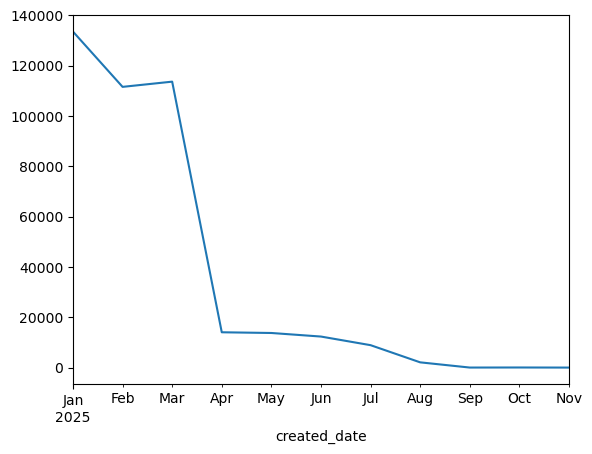

In [22]:
df.groupby(df['created_date'].dt.to_period('M')).size().plot()

Most Common request types

In [23]:
result = duckdb.sql("SELECT RequestType, COUNT(RequestType) as amount FROM df GROUP BY RequestType ORDER BY amount DESC").show()

┌────────────────────────────┬────────┐
│        RequestType         │ amount │
│          varchar           │ int64  │
├────────────────────────────┼────────┤
│ bulky items                │ 166033 │
│ graffiti removal           │ 135722 │
│ illegal dumping pickup     │  30797 │
│ metal/household appliances │  25988 │
│ homeless encampment        │  24100 │
│ electronic waste           │   9828 │
│ dead animal removal        │   6502 │
│ multiple streetlight issue │   4559 │
│ single streetlight issue   │   3075 │
│ other                      │   2756 │
│ report water waste         │    357 │
│ feedback                   │    155 │
├────────────────────────────┴────────┤
│ 12 rows                   2 columns │
└─────────────────────────────────────┘



Average response time by type

On average, how long does it take to resolve the request from slowest to fastest

In [24]:
duckdb.sql("SELECT RequestType, AVG(response_time_days) as response_time FROM df_closed GROUP BY REquestType ORDER BY response_time DESC ").show()

┌────────────────────────────┬──────────────────────┐
│        RequestType         │    response_time     │
│          varchar           │        double        │
├────────────────────────────┼──────────────────────┤
│ Single Streetlight Issue   │     85.6409756097561 │
│ Multiple Streetlight Issue │    70.92235139284931 │
│ Graffiti Removal           │      2.5728990141613 │
│ Illegal Dumping Pickup     │   2.5128421599506447 │
│ Metal/Household Appliances │    2.498807141757734 │
│ Electronic Waste           │   2.4301994301994303 │
│ Bulky Items                │   2.3742689706263214 │
│ Feedback                   │   0.8580645161290322 │
│ Other                      │   0.3751814223512337 │
│ Dead Animal Removal        │  0.23346662565364504 │
│ Homeless Encampment        │ 0.013029045643153526 │
│ Report Water Waste         │                  0.0 │
├────────────────────────────┴──────────────────────┤
│ 12 rows                                 2 columns │
└───────────────────────────

Open vs Closed requests

In [25]:
duckdb.sql("SELECT status, COUNT(status) as total FROM df GROUP BY status").show()

┌──────────────┬────────┐
│    Status    │ total  │
│   varchar    │ int64  │
├──────────────┼────────┤
│ Closed       │ 388310 │
│ Referred Out │    403 │
│ Cancelled    │  21156 │
│ Pending      │      3 │
└──────────────┴────────┘



In [26]:
df.to_csv("la311_full.csv", index=False)
df_closed.to_csv("la311_closed.csv", index=False)